In [1]:
import wandb
import matplotlib as mpl
import matplotlib.pyplot as plt
import collections
import numpy as np
import pandas as pd

api = wandb.Api(timeout=39)

# Define your project and entity (replace with your specific values)
entity = "wang-kevin3290-princeton-university"  # e.g., your username or team name
project = "clean_JaxGCRL_test"


In [2]:
allData = {} # store the data with key of env id and value (nested dictionary). first key is depth. 2nd is batch size

In [3]:
import collections
import numpy as np

def get_avgs(runs_api):
    # Local filters
    runs = []

    for run in runs_api:
        # Check it actually has num_epoch steps completed
        if '_step' not in run.summary.keys():
            continue
        if run.summary['_step'] != run.config['num_epochs'] - 1:
            continue

        # Check valid depths and batch sizes
        actor_depth = run.config['actor_depth']
        critic_depth = run.config['critic_depth']
        batch_size = run.config['batch_size']

        if actor_depth not in valid_depths:
            continue
        if actor_depth != critic_depth:
            continue
        if batch_size not in valid_batchSizes:
            continue

        runs.append(run)

    # Gather the raw metric curves grouped by depth and batch size
    depth_batch_curves = collections.defaultdict(lambda: collections.defaultdict(list))
    seeds = collections.defaultdict(lambda: collections.defaultdict(list))

    for run in runs:
        depth = run.config['actor_depth']
        batch_size = run.config['batch_size']
        seed = run.config.get('seed', 'unknown')  # Get the seed, defaulting to 'unknown' if not set

        # Pull the full training history
        hist = run.history()
        if metric not in hist.columns:
            print(f"WARNING: metric not found in hist.columns for depth {depth}, batch size {batch_size}, seed {run.config['seed']}, continuing...")
            continue

        values = hist[metric].values  # shape = (num_epochs,)
        depth_batch_curves[depth][batch_size].append(values)
        seeds[depth][batch_size].append(seed)  # Store the seed with the corresponding group

    print("Completed part 1")

    # Compute mean for each depth and batch size
    allData = collections.defaultdict(lambda: collections.defaultdict(list))

    for depth in valid_depths:
        for batch_size in valid_batchSizes:
            curves = depth_batch_curves[depth][batch_size]
            if len(curves) == 0:
                continue
            seed_list = seeds[depth][batch_size]  # List of seeds corresponding to curves

            # Special case for batch_size == 512
            print(depth, batch_size, len(curves))
            if batch_size == 512:
                if depth == 8:
                    try:
                        index = seed_list.index(271)
                        mean_curve = curves[index]
                    except ValueError:
                        print("Seed 271 not found for depth 8, batch size 512")
                        continue
                elif depth == 4:
                    try:
                        index = seed_list.index(405)
                        mean_curve = curves[index]
                    except ValueError:
                        print("Seed 405 not found for depth 4, batch size 512")
                        continue
                elif depth == 16:
                    try:
                        index = seed_list.index(594)
                        mean_curve = curves[index]
                    except ValueError:
                        print("Seed 594 not found for depth 16, batch size 512")
                        continue
                elif depth == 64:
                    try:
                        index = seed_list.index(886)
                        mean_curve = curves[index]
                    except ValueError:
                        print("Seed 886 not found for depth 64, batch size 512")
                        continue
                else:
                    # Default calculation for other depths
                    arr = np.stack(curves, axis=0)  # e.g., (N_runs, num_epochs)
                    mean_curve = arr.mean(axis=0)
            else:
                # Default calculation for other batch sizes
                arr = np.stack(curves, axis=0)  # e.g., (N_runs, num_epochs)
                mean_curve = arr.mean(axis=0)

            allData[depth][batch_size] = mean_curve


    return allData


In [4]:
def getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_depths):
    filters = {
        "config.env_id": env_id,
        "config.eval_env_id": eval_env_id if eval_env_id else {"$in": ['', None, env_id]}, #{"$ne": "xxx"}, #
        "config.num_envs": 512,
        "config.num_sgd_batches_per_training_step": 800,
        "config.critic_network_width": 256,
#         "config.batch_size": 512,
#         "config.actor_depth": 4,
        "config.num_epochs": {"$in": [num_epochs]}, #num_epochs,
        "config.disable_entropy": {"$ne": 1},
        "config.use_relu": {"$ne": 1},
        "config.resnet": "noishmistake4_nodense",
        "config.dropout": None,
        "config.logsumexp_penalty_coeff": {"$in": [None, 0.1]},
    }

    runs_api = api.runs(path=f"{entity}/{project}", filters=filters) #runs filtered by wandb api
    return runs_api

In [5]:
env_id = "humanoid"
env_title = env_id.replace("_", " ").title()
eval_env_id = None #"humanoid_big_maze_eval"
metric = 'eval/episode_success'
metric_label = "Success"
num_epochs = 100
valid_depths = [4, 8, 16, 64]
valid_widths = [128, 256, 512, 1024, 2048, 4096]
valid_batchSizes = [128, 256, 512, 1024, 2048]
runs_api = getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_widths)
print(len(runs_api))

allData = get_avgs(runs_api)

120
Completed part 1
4 128 2
4 256 2
4 512 5
4 1024 2
4 2048 2
8 128 2
8 256 2
8 512 5
8 1024 2
8 2048 2
16 128 2
16 256 2
16 512 6
16 1024 2
16 2048 2
64 128 2
64 256 2
64 512 6
64 1024 2
64 2048 2


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def plot_depth_batch(allData, nrows, ncols, rc_params=None, figsize=(12, 7), colors=None, average_every=1, linewidth=2, y_maxes=None):
    # Update mpl.rcParams with provided rc_params, if any
    if rc_params:
        for param, value in rc_params.items():
            mpl.rcParams[param] = value

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()  # Flatten the axes array for easier indexing

    def downsample_curve(curve, step):
        # Average every `step` points in the curve
        return [np.mean(curve[i:i + step]) for i in range(0, len(curve), step)]

    for i, (depth, batch_data) in enumerate(allData.items()):
        if i >= len(axs):
            print(f"Warning: Not enough subplots for all depths.")
            break

        ax = axs[i]
        ax.set_title(f"Depth {depth}", pad=10)

        for j, (batch_size, mean_curve) in enumerate(batch_data.items()):
            # Downsample mean_curve based on average_every
            downsampled_mean = downsample_curve(mean_curve, average_every)

            color = colors[j % len(colors)] if colors else None  # Use provided color or default
            ax.plot(
                np.arange(len(downsampled_mean)) * average_every,
                downsampled_mean,
                label=f"{batch_size}",
                color=color,
                linewidth=linewidth
            )

        # Only label the bottom row subplots
        if i >= 2:
            ax.set_xlabel("Env step (M)", fontsize=19, labelpad=5)

        # Only label the first column subplots
        if i % 2 == 0:
            ax.set_ylabel("Success")

        ax.grid(True, alpha=0.3)

        # Set y-axis limit if y_maxes is provided
        if y_maxes and i < len(y_maxes):
            ax.set_ylim(top=y_maxes[i])

    for ax in axs:
        ax.spines['top'].set_color('#000000')  # Set top border to black
        ax.spines['bottom'].set_color('#000000')  # Set bottom border to black
        ax.spines['left'].set_color('#000000')  # Set left border to black
        ax.spines['right'].set_color('#000000')  # Set right border to black
        ax.spines['top'].set_linewidth(2)  # Optional: Make borders thicker
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    # Create legend from the first subplot
    handles, labels = axs[0].get_legend_handles_labels()
    legend_handles = [mpl.lines.Line2D([], [], color=h.get_color(), linewidth=5) for h in handles]
    
    # Add "Batch Size:" label manually
    legend_handles.insert(0, mpl.lines.Line2D([], [], color='none'))
    labels.insert(0, "Batch Size:")

    # Adjust subplot border colors
    for ax in axs:
        ax.spines['top'].set_color('#999999')
        ax.spines['bottom'].set_color('#999999')
        ax.spines['left'].set_color('#999999')
        ax.spines['right'].set_color('#999999')

    # Place the legend below all subplots
    fig.legend(
        legend_handles,
        labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(labels),
        prop={'size': rc_params["legend.fontsize"], 'weight': 500},
        columnspacing=1.7,
        borderpad=0.5
    )

    # Use h_pad to add vertical padding between subplot rows
    plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=2.5)
    plt.show()


128
256
512
1024
2048
128
256
512
1024
2048
128
256
512
1024
2048
128
256
512
1024
2048


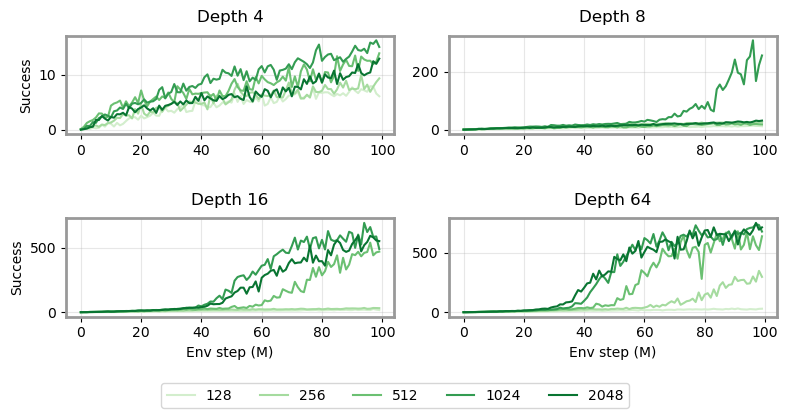

In [12]:
mpl.rcdefaults()

# 92c6e2
# Call the function with the specified rcParams and figure size
# plot_depth_batch(allData, nrows=2, ncols=2, rc_params=rc_params, 
#                    figsize=(15, 11), colors = colors, average_every = 1, 
#                    linewidth=3,
#                 y_maxes = [50, 120, 700, 800],)

nrows = 2
ncols = 2
average_every = 1

# def plot_depth_batch(allData, nrows, ncols, rc_params=None, figsize=(12, 7), colors=None, average_every=1, linewidth=2, y_maxes=None):
#     # Update mpl.rcParams with provided rc_params, if any
#     if rc_params:
#         for param, value in rc_params.items():
#             mpl.rcParams[param] = value

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 4))
axs = axs.flatten()  # Flatten the axes array for easier indexing

def downsample_curve(curve, step):
    # Average every `step` points in the curve
    return [np.mean(curve[i:i + step]) for i in range(0, len(curve), step)]


values = np.linspace(0.2, 1, 6)
colors = [plt.cm.Greens(v) for v in values]
for i, (depth, batch_data) in enumerate(allData.items()):
    if i >= len(axs):
        print(f"Warning: Not enough subplots for all depths.")
        break

    ax = axs[i]
    ax.set_title(f"Depth {depth}", pad=10)

    for j, (c, (batch_size, mean_curve)) in enumerate(zip(colors, sorted(batch_data.items()))):
        print(batch_size)
        # Downsample mean_curve based on average_every
        downsampled_mean = downsample_curve(mean_curve, average_every)

        # color = colors[j % len(colors)] if colors else None  # Use provided color or default
        ax.plot(
            np.arange(len(downsampled_mean)) * average_every,
            downsampled_mean,
            label=f"{batch_size}",
            color=c,
        )

    # Only label the bottom row subplots
    if i >= 2:
        ax.set_xlabel("Env step (M)")

    # Only label the first column subplots
    if i % 2 == 0:
        ax.set_ylabel("Success")

    ax.grid(True, alpha=0.3)
    if i == 0:
        leg = fig.legend(
            # legend_handles,
            # labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.05),
            ncol=5,
            # prop={'size': rc_params["legend.fontsize"], 'weight': 500},
            # columnspacing=1.7,
            # borderpad=0.5
        )

    # Set y-axis limit if y_maxes is provided
    # if y_maxes and i < len(y_maxes):
    #     ax.set_ylim(top=y_maxes[i])

for ax in axs:
    ax.spines['top'].set_color('#000000')  # Set top border to black
    ax.spines['bottom'].set_color('#000000')  # Set bottom border to black
    ax.spines['left'].set_color('#000000')  # Set left border to black
    ax.spines['right'].set_color('#000000')  # Set right border to black
    ax.spines['top'].set_linewidth(2)  # Optional: Make borders thicker
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
# Create legend from the first subplot
# handles, labels = axs[0].get_legend_handles_labels()
# legend_handles = [mpl.lines.Line2D([], [], color=h.get_color(), linewidth=5) for h in handles]

# Add "Batch Size:" label manually
# legend_handles.insert(0, mpl.lines.Line2D([], [], color='none'))
# labels.insert(0, "Batch Size:")

# Adjust subplot border colors
for ax in axs:
    ax.spines['top'].set_color('#999999')
    ax.spines['bottom'].set_color('#999999')
    ax.spines['left'].set_color('#999999')
    ax.spines['right'].set_color('#999999')

# Place the legend below all subplots


# Use h_pad to add vertical padding between subplot rows
plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=2.5)
plt.savefig("batch-size.pdf", bbox_inches="tight", bbox_extra_artists=(leg,))
plt.show()

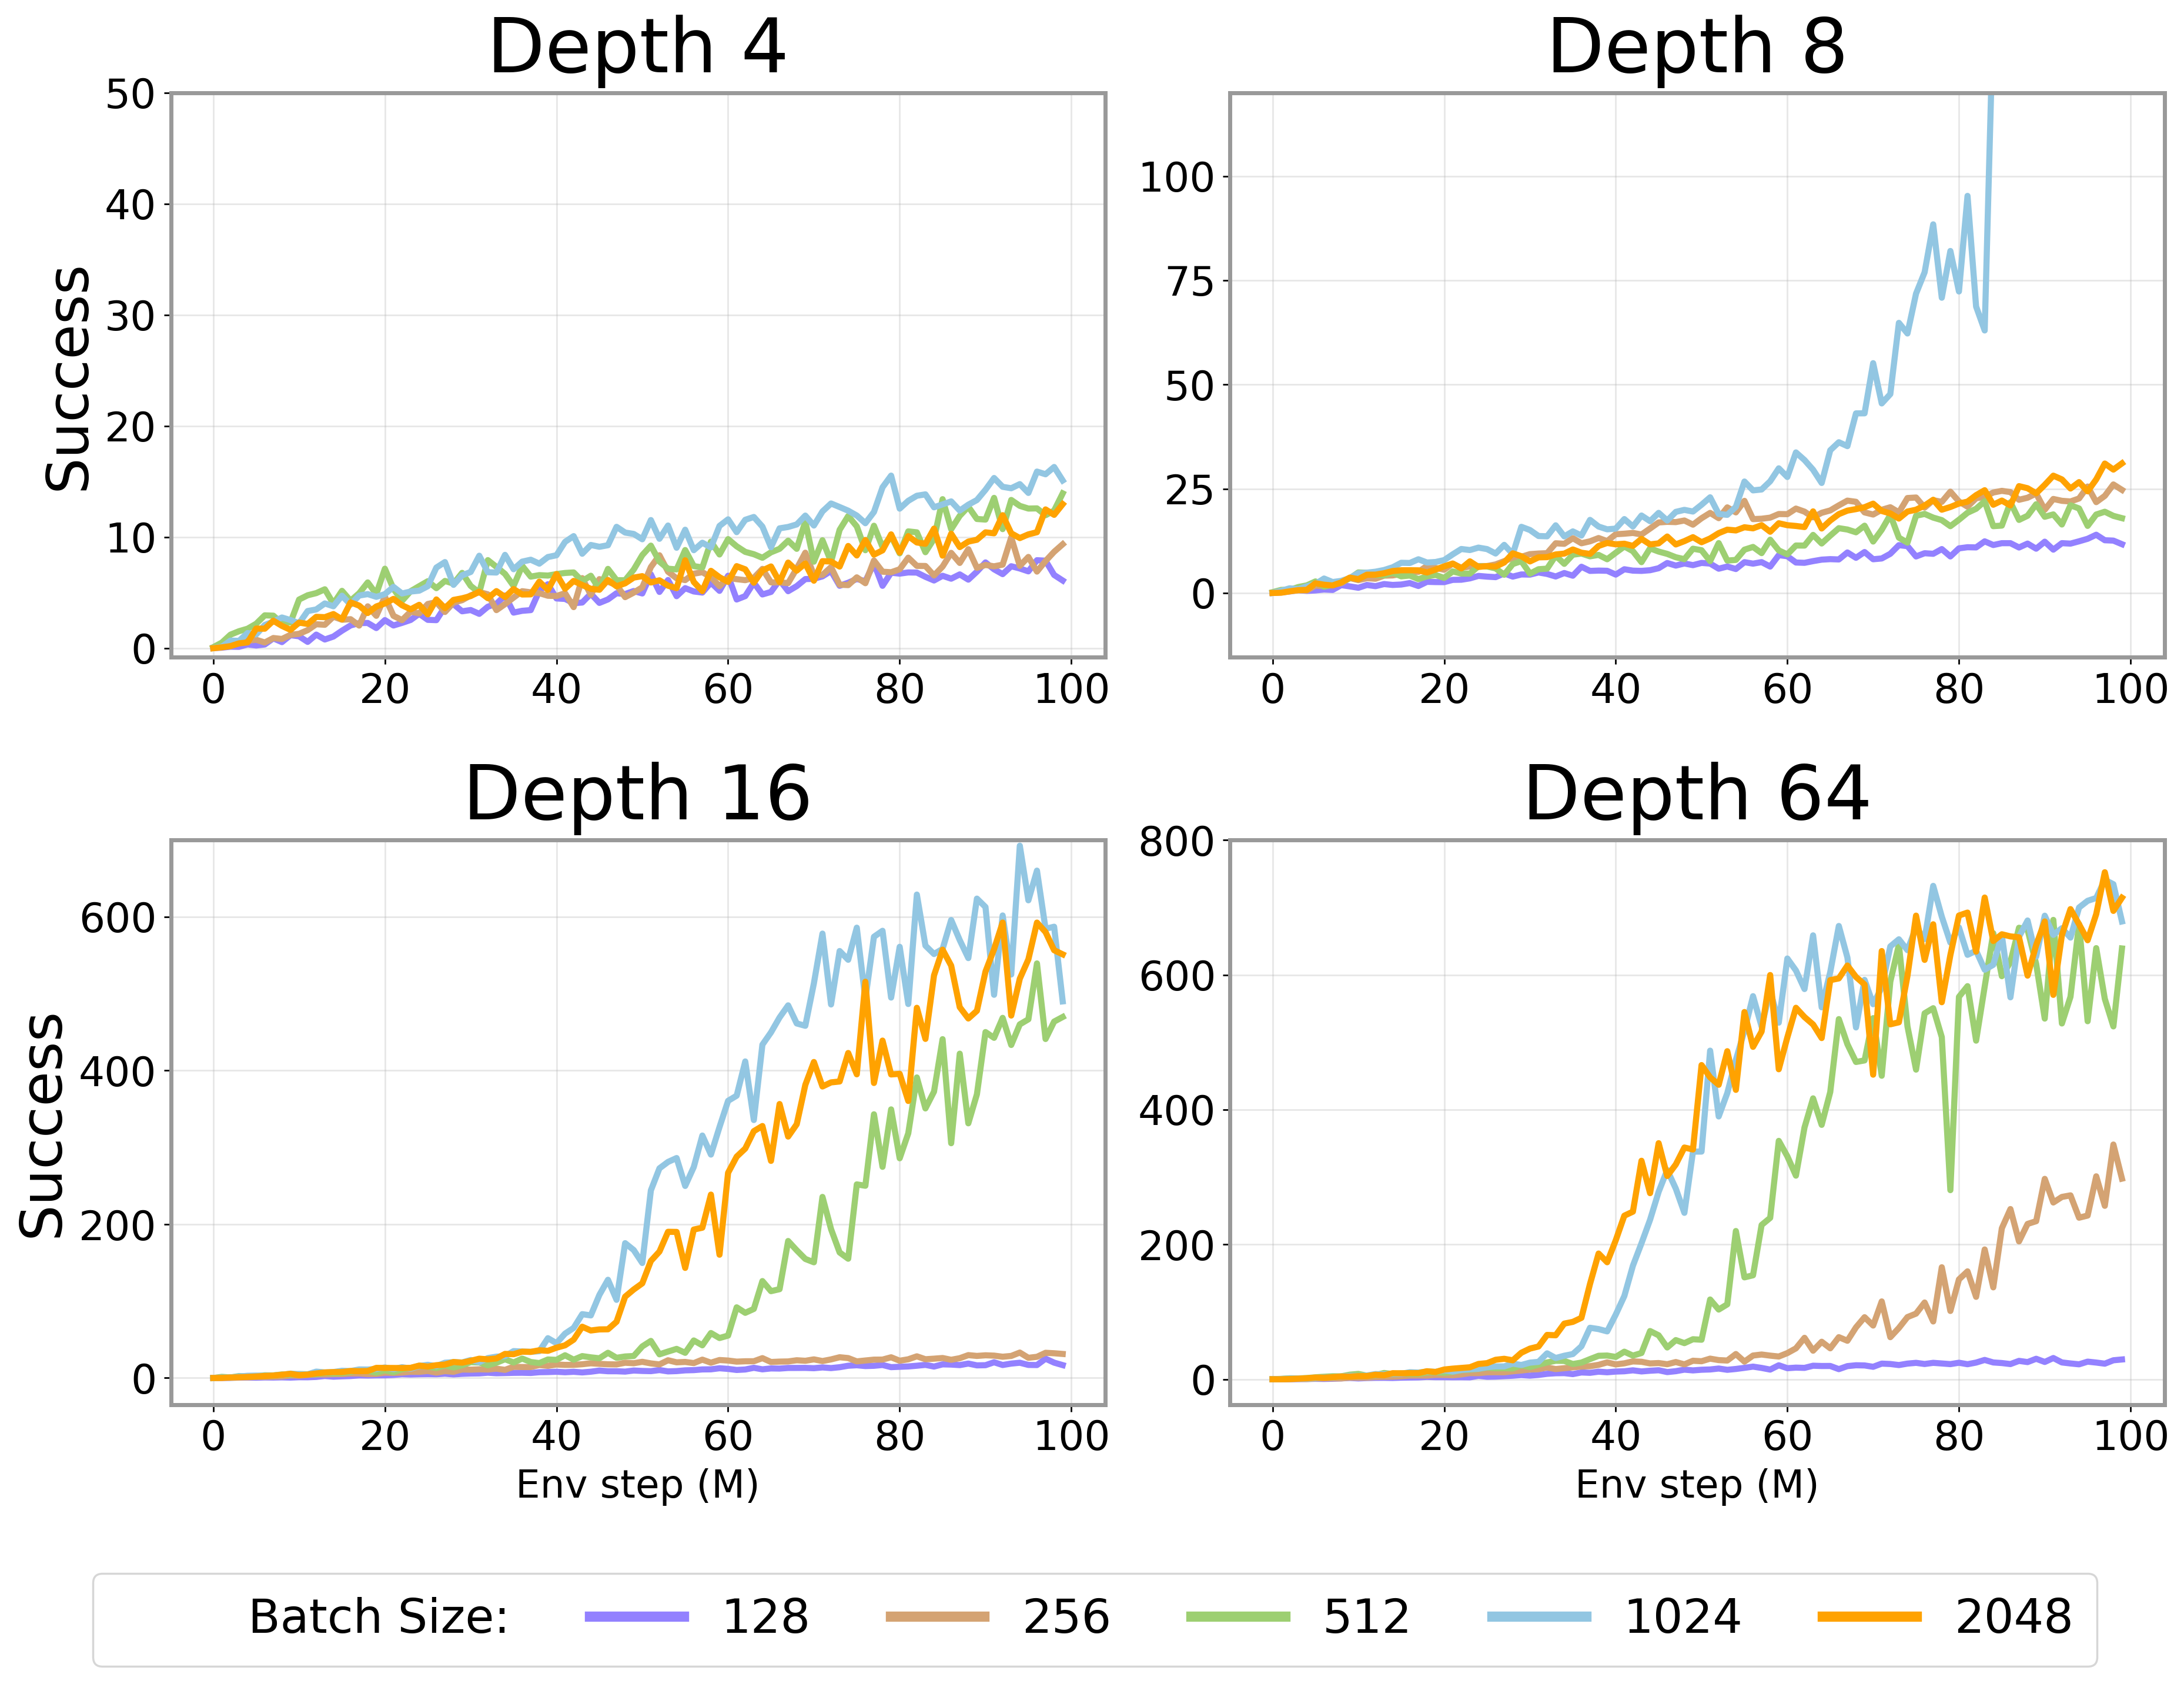

In [7]:
# rc_params = {
#     'figure.dpi': 250,
#     'axes.titlesize': 37,
#     'axes.labelsize': 28,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 23,
# }

# colors = ['#9381ff', '#d4a373',  '#9dcf72', '#92c6e2', '#ffa200', ]

# # 92c6e2
# # Call the function with the specified rcParams and figure size
# plot_depth_batch(allData, nrows=2, ncols=2, rc_params=rc_params, 
#                    figsize=(15, 11), colors = colors, average_every = 1, 
#                    linewidth=3,
#                 y_maxes = [50, 120, 700, 800],)
